# Data Preparation: Clinical Trial Screening Dataset

This notebook prepares the oncology trial screening dataset for model training:
1. Load raw data
2. Filter to most recent note per patient
3. Create STATUS labels based on priority rules
4. Verify data quality and class distribution
5. Create stratified train/validation/test split (70/15/15)
6. Save processed dataset

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Imports successful!")

Imports successful!


## Step 1: Load Raw Data

In [2]:
# For local execution
data_path = '../data/oncology_trial_screening_v06.csv'

# For Google Colab (uncomment and use if needed)
# from google.colab import drive
# drive.mount('/content/drive')
# data_path = '/content/drive/My Drive/path/to/oncology_trial_screening_v02.csv'

df_raw = pd.read_csv(data_path)

print(f"Dataset shape: {df_raw.shape}")
print(f"\nColumn names:\n{df_raw.columns.tolist()}")
print(f"\nFirst few rows:")
df_raw.head()

Dataset shape: (3056, 10)

Column names:
['patient_id', 'note_date', 'note_type', 'cancer_indication', 'free_text_note', 'eligible', 'available', 'deceased', 'lost_to_follow_up', 'label_correct']

First few rows:


,patient_id,note_date,note_type,cancer_indication,free_text_note,eligible,available,deceased,lost_to_follow_up,label_correct
0,PT0001,2021-09-10,interim,Renal Cell Carcinoma,Renal Cell Carcinoma (T1N0M1). IMDC: fav; VHL:...,0,0,0,0,1
1,PT0001,2021-10-04,final,Renal Cell Carcinoma,Renal Cell Carcinoma (T1N0M1). VHL: mut; IMDC=...,0,0,0,1,1
2,PT0002,2023-01-28,final,Head and Neck Squamous Cell Carcinoma (HNSCC),Head and Neck Squamous Cell Carcinoma (HNSCC) ...,0,1,0,0,1
3,PT0003,2024-03-29,interim,Endometrial Cancer,Endometrial Cancer (T4N1M1). p53: mut; POLE=ED...,0,0,0,0,1
4,PT0003,2024-03-31,final,Endometrial Cancer,Endometrial Cancer (T4N1M1). MSI=MSS/ ER: neg....,0,0,0,1,1


## Step 2: Data Quality Check

In [3]:
# Check for missing values
print("Missing values per column:")
print(df_raw.isnull().sum())

print(f"\nData types:")
print(df_raw.dtypes)

# Check date format
print(f"\nDate range: {df_raw['note_date'].min()} to {df_raw['note_date'].max()}")

# Unique patients
print(f"\nTotal unique patients: {df_raw['patient_id'].nunique()}")
print(f"Total notes: {len(df_raw)}")
print(f"Average notes per patient: {len(df_raw) / df_raw['patient_id'].nunique():.2f}")

Missing values per column:
patient_id           0
note_date            0
note_type            0
cancer_indication    0
free_text_note       0
eligible             0
available            0
deceased             0
lost_to_follow_up    0
label_correct        0
dtype: int64

Data types:
patient_id             str
note_date              str
note_type              str
cancer_indication      str
free_text_note         str
eligible             int64
available            int64
deceased             int64
lost_to_follow_up    int64
label_correct        int64
dtype: object

Date range: 2021-01-16 to 2025-01-16

Total unique patients: 1000
Total notes: 3056
Average notes per patient: 3.06


## Step 3: Filter to Most Recent Note per Patient

In [4]:
# Convert note_date to datetime if not already
df_raw['note_date'] = pd.to_datetime(df_raw['note_date'])

# Sort by patient_id and note_date to ensure proper ordering
df_raw = df_raw.sort_values(['patient_id', 'note_date'])

# Get most recent note per patient: works up to v5 of data 
#df_latest = df_raw.loc[df_raw.groupby('patient_id')['note_date'].idxmax()].reset_index(drop=True)

# Get the "final" record for the patient for v6 of the data
df_latest = (df_raw[df_raw['note_type'] == 'final']
               .loc[df_raw[df_raw['note_type'] == 'final']
               .groupby('patient_id')['note_date'].idxmax()]
               .reset_index(drop=True))

print(f"Dataset after filtering to latest note per patient:")
print(f"Shape: {df_latest.shape}")
print(f"\nVerification - unique patients: {df_latest['patient_id'].nunique()}")
print(f"\nFirst few rows:")
df_latest.head()

Dataset after filtering to latest note per patient:
Shape: (1000, 10)

Verification - unique patients: 1000

First few rows:


,patient_id,note_date,note_type,cancer_indication,free_text_note,eligible,available,deceased,lost_to_follow_up,label_correct
0,PT0001,2021-10-04,final,Renal Cell Carcinoma,Renal Cell Carcinoma (T1N0M1). VHL: mut; IMDC=...,0,0,0,1,1
1,PT0002,2023-01-28,final,Head and Neck Squamous Cell Carcinoma (HNSCC),Head and Neck Squamous Cell Carcinoma (HNSCC) ...,0,1,0,0,1
2,PT0003,2024-03-31,final,Endometrial Cancer,Endometrial Cancer (T4N1M1). MSI=MSS/ ER: neg....,0,0,0,1,1
3,PT0004,2024-05-06,final,Endometrial Cancer,Endometrial Cancer (T3N2M0). p53: mut/ MSI=MSI...,0,0,0,1,1
4,PT0005,2021-06-27,final,Non-Small Cell Lung Cancer (NSCLC),Non-Small Cell Lung Cancer (NSCLC) (T1N0M0). K...,0,0,0,0,1


## Step 4: Create STATUS Label

Priority rules:
1. If `deceased = 1` → 'DECEASED'
2. Elif `lost_to_follow_up = 1` → 'CENSORED'
3. Elif `available = 1 and eligible = 1` → 'AVAILABLE'
4. Elif `available = 0 and eligible = 1` → 'ELIGIBLE'
5. Else (`eligible = 0`) → 'INELIGIBLE'

In [5]:
def create_status_label(row):
    """
    Create STATUS label based on priority rules.
    
    Args:
        row: A row from the dataframe with columns: deceased, lost_to_follow_up, available, eligible
    
    Returns:
        Status label as string
    """
    if row['deceased'] == 1:
        return 'DECEASED'
    elif row['lost_to_follow_up'] == 1:
        return 'CENSORED'
    elif row['available'] == 1 and row['eligible'] == 1:
        return 'AVAILABLE'
    elif row['available'] == 0 and row['eligible'] == 1:
        return 'ELIGIBLE'
    else:  # eligible == 0
        return 'INELIGIBLE'

# Apply the function to create STATUS column
df_latest['STATUS'] = df_latest.apply(create_status_label, axis=1)

print("STATUS label created successfully!")
print(f"\nSample rows with STATUS:")
print(df_latest[['patient_id', 'deceased', 'lost_to_follow_up', 'available', 'eligible', 'STATUS']].head(10))

STATUS label created successfully!

Sample rows with STATUS:
  patient_id  deceased  lost_to_follow_up  available  eligible      STATUS
0     PT0001         0                  1          0         0    CENSORED
1     PT0002         0                  0          1         0  INELIGIBLE
2     PT0003         0                  1          0         0    CENSORED
3     PT0004         0                  1          0         0    CENSORED
4     PT0005         0                  0          0         0  INELIGIBLE
5     PT0006         0                  0          0         0  INELIGIBLE
6     PT0007         0                  0          1         0  INELIGIBLE
7     PT0008         0                  0          1         0  INELIGIBLE
8     PT0009         1                  0          0         0    DECEASED
9     PT0010         0                  0          0         0  INELIGIBLE


## Step 5: Verify Class Distribution

Class Distribution:
INELIGIBLE      :  480 ( 48.0%)
AVAILABLE       :  147 ( 14.7%)
CENSORED        :  142 ( 14.2%)
ELIGIBLE        :  126 ( 12.6%)
DECEASED        :  105 ( 10.5%)
TOTAL           : 1000


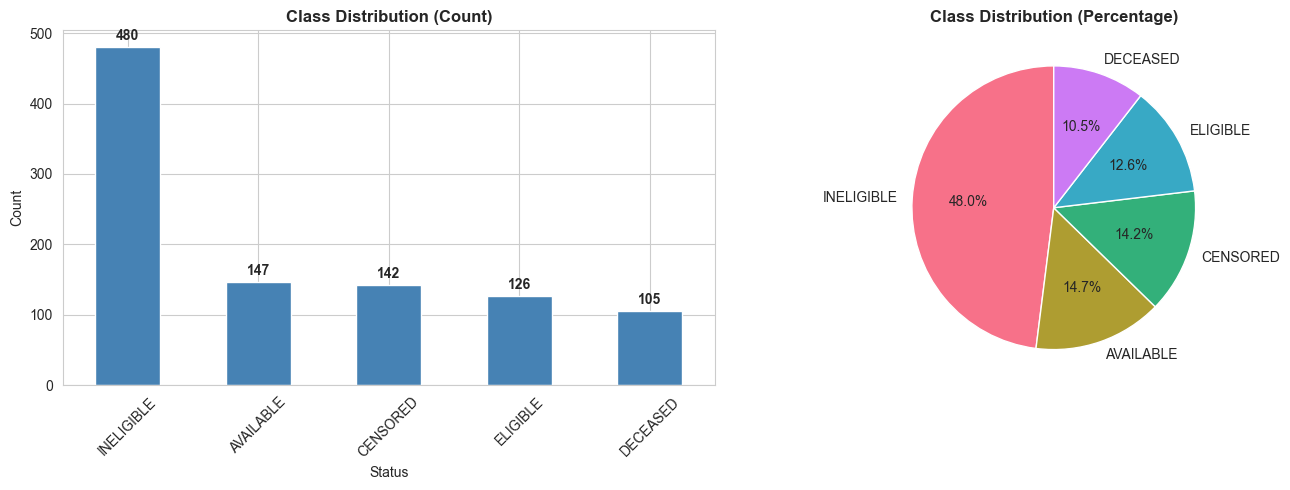


Visualization saved as 'class_distribution.png'


In [6]:
# Class distribution
status_counts = df_latest['STATUS'].value_counts()
status_percentages = df_latest['STATUS'].value_counts(normalize=True) * 100

print("Class Distribution:")
print("="*50)
for status in status_counts.index:
    count = status_counts[status]
    percentage = status_percentages[status]
    print(f"{status:15} : {count:4} ({percentage:5.1f}%)")
print("="*50)
print(f"{'TOTAL':15} : {len(df_latest):4}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
status_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
colors = sns.color_palette('husl', len(status_counts))
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'class_distribution.png'")

## Step 6: Create Stratified Train/Validation/Test Split

Split ratio: 70% train, 15% validation, 15% test
Stratification: By STATUS class to maintain distribution

Train set size: 700 (70.0%)
Validation set size: 150 (15.0%)
Test set size: 150 (15.0%)
Total: 1000

Class distribution across splits:
            Train  Validation  Test  Overall
STATUS                                      
AVAILABLE    14.7        14.7  14.7     14.7
CENSORED     14.1        14.0  14.7     14.2
DECEASED     10.6        10.7  10.0     10.5
ELIGIBLE     12.6        12.7  12.7     12.6
INELIGIBLE   48.0        48.0  48.0     48.0


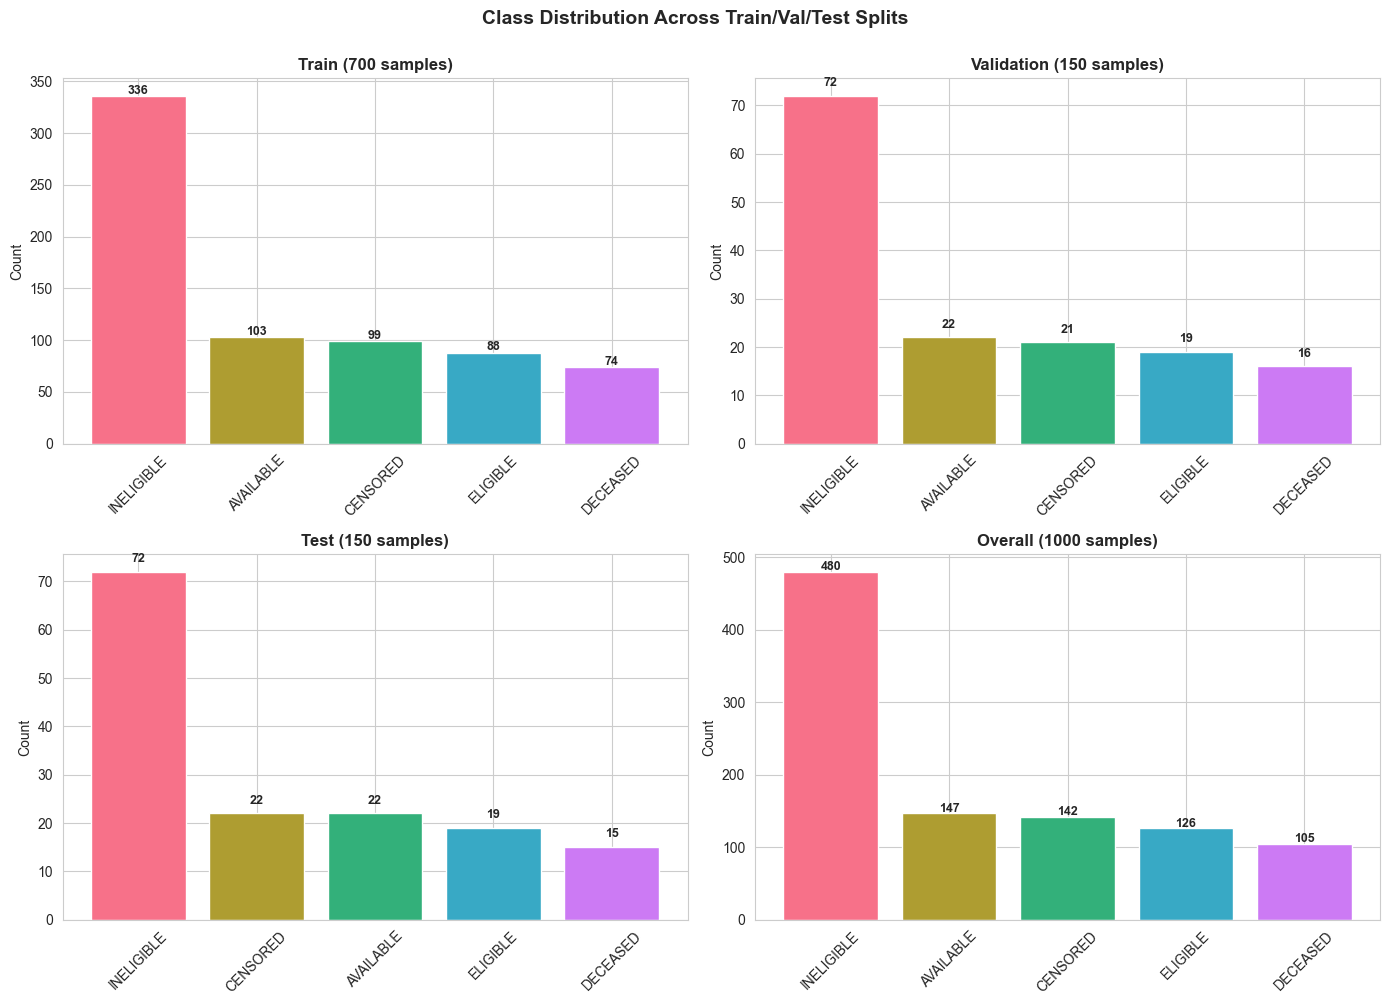


Visualization saved as 'split_distribution.png'


In [7]:
# Create stratified split: first split into train (70%) and temp (30%)
df_train, df_temp = train_test_split(
    df_latest,
    test_size=0.30,
    random_state=42,
    stratify=df_latest['STATUS']
)

# Then split temp into validation (50% of 30% = 15%) and test (50% of 30% = 15%)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    random_state=42,
    stratify=df_temp['STATUS']
)

print(f"Train set size: {len(df_train)} ({len(df_train)/len(df_latest)*100:.1f}%)")
print(f"Validation set size: {len(df_val)} ({len(df_val)/len(df_latest)*100:.1f}%)")
print(f"Test set size: {len(df_test)} ({len(df_test)/len(df_latest)*100:.1f}%)")
print(f"Total: {len(df_train) + len(df_val) + len(df_test)}")

# Verify stratification
print("\n" + "="*70)
print("Class distribution across splits:")
print("="*70)

splits_data = {
    'Train': df_train['STATUS'].value_counts(normalize=True) * 100,
    'Validation': df_val['STATUS'].value_counts(normalize=True) * 100,
    'Test': df_test['STATUS'].value_counts(normalize=True) * 100,
    'Overall': df_latest['STATUS'].value_counts(normalize=True) * 100
}

splits_df = pd.DataFrame(splits_data).round(1)
print(splits_df)

# Visualize split distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Class Distribution Across Train/Val/Test Splits', fontsize=14, fontweight='bold', y=1.00)

split_names = ['Train', 'Validation', 'Test', 'Overall']
datasets = [df_train, df_val, df_test, df_latest]

for idx, (ax, split_name, dataset) in enumerate(zip(axes.flatten(), split_names, datasets)):
    status_dist = dataset['STATUS'].value_counts()
    colors = sns.color_palette('husl', len(status_dist))
    ax.bar(status_dist.index, status_dist.values, color=colors)
    ax.set_title(f'{split_name} ({len(dataset)} samples)', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    # Add count labels on bars
    for i, v in enumerate(status_dist.values):
        ax.text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('split_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'split_distribution.png'")

## Step 7: Prepare Final Dataset

In [8]:
# Add split column to original dataframe for reference
df_latest['split'] = 'unknown'
df_latest.loc[df_train.index, 'split'] = 'train'
df_latest.loc[df_val.index, 'split'] = 'validation'
df_latest.loc[df_test.index, 'split'] = 'test'

# Select relevant columns for final dataset
final_columns = ['patient_id', 'note_date', 'cancer_indication', 'free_text_note', 
                  'eligible', 'available', 'deceased', 'lost_to_follow_up', 'STATUS', 'split']

df_processed = df_latest[final_columns].copy()

print(f"Final processed dataset shape: {df_processed.shape}")
print(f"\nColumns: {df_processed.columns.tolist()}")
print(f"\nFirst few rows:")
df_processed.head()

Final processed dataset shape: (1000, 10)

Columns: ['patient_id', 'note_date', 'cancer_indication', 'free_text_note', 'eligible', 'available', 'deceased', 'lost_to_follow_up', 'STATUS', 'split']

First few rows:


,patient_id,note_date,cancer_indication,free_text_note,eligible,available,deceased,lost_to_follow_up,STATUS,split
0,PT0001,2021-10-04,Renal Cell Carcinoma,Renal Cell Carcinoma (T1N0M1). VHL: mut; IMDC=...,0,0,0,1,CENSORED,validation
1,PT0002,2023-01-28,Head and Neck Squamous Cell Carcinoma (HNSCC),Head and Neck Squamous Cell Carcinoma (HNSCC) ...,0,1,0,0,INELIGIBLE,train
2,PT0003,2024-03-31,Endometrial Cancer,Endometrial Cancer (T4N1M1). MSI=MSS/ ER: neg....,0,0,0,1,CENSORED,train
3,PT0004,2024-05-06,Endometrial Cancer,Endometrial Cancer (T3N2M0). p53: mut/ MSI=MSI...,0,0,0,1,CENSORED,test
4,PT0005,2021-06-27,Non-Small Cell Lung Cancer (NSCLC),Non-Small Cell Lung Cancer (NSCLC) (T1N0M0). K...,0,0,0,0,INELIGIBLE,train


## Step 8: Save Processed Dataset

In [9]:
# Save the full processed dataset
output_path = 'processed_data.csv'
df_processed.to_csv(output_path, index=False)
print(f"✓ Full processed dataset saved to: {output_path}")

# Also save splits separately for convenience
df_train.to_csv('train_data.csv', index=False)
df_val.to_csv('validation_data.csv', index=False)
df_test.to_csv('test_data.csv', index=False)
print(f"✓ Train set saved to: train_data.csv")
print(f"✓ Validation set saved to: validation_data.csv")
print(f"✓ Test set saved to: test_data.csv")

# Save class mapping for reference
class_mapping = {status: idx for idx, status in enumerate(sorted(df_latest['STATUS'].unique()))}
print(f"\nClass mapping:")
for status, idx in sorted(class_mapping.items()):
    print(f"  {status:15} → {idx}")

# Save mapping to file
import json
with open('class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)
print(f"\n✓ Class mapping saved to: class_mapping.json")

✓ Full processed dataset saved to: processed_data.csv
✓ Train set saved to: train_data.csv
✓ Validation set saved to: validation_data.csv
✓ Test set saved to: test_data.csv

Class mapping:
  AVAILABLE       → 0
  CENSORED        → 1
  DECEASED        → 2
  ELIGIBLE        → 3
  INELIGIBLE      → 4

✓ Class mapping saved to: class_mapping.json


## Summary

In [10]:
print("\n" + "="*70)
print("DATA PREPARATION SUMMARY")
print("="*70)
print(f"\n✓ Loaded raw dataset: {df_raw.shape[0]} rows")
print(f"✓ Filtered to latest note per patient: {df_latest.shape[0]} rows")
print(f"✓ Created STATUS labels using priority rules")
print(f"\nClass Distribution:")
for status in sorted(df_latest['STATUS'].unique()):
    count = (df_latest['STATUS'] == status).sum()
    percentage = count / len(df_latest) * 100
    print(f"  {status:15} : {count:4} ({percentage:5.1f}%)")

print(f"\n✓ Created stratified train/val/test split:")
print(f"  Train   : {len(df_train):4} samples (70%)")
print(f"  Validation: {len(df_val):4} samples (15%)")
print(f"  Test    : {len(df_test):4} samples (15%)")

print(f"\n✓ Saved processed datasets:")
print(f"  - processed_data.csv (full dataset with split labels)")
print(f"  - train_data.csv")
print(f"  - validation_data.csv")
print(f"  - test_data.csv")
print(f"  - class_mapping.json")

print(f"\n✓ Generated visualizations:")
print(f"  - class_distribution.png")
print(f"  - split_distribution.png")

print("\n" + "="*70)
print("Ready for model training! Proceed to notebook 02 or 03.")
print("="*70)


DATA PREPARATION SUMMARY

✓ Loaded raw dataset: 3056 rows
✓ Filtered to latest note per patient: 1000 rows
✓ Created STATUS labels using priority rules

Class Distribution:
  AVAILABLE       :  147 ( 14.7%)
  CENSORED        :  142 ( 14.2%)
  DECEASED        :  105 ( 10.5%)
  ELIGIBLE        :  126 ( 12.6%)
  INELIGIBLE      :  480 ( 48.0%)

✓ Created stratified train/val/test split:
  Train   :  700 samples (70%)
  Validation:  150 samples (15%)
  Test    :  150 samples (15%)

✓ Saved processed datasets:
  - processed_data.csv (full dataset with split labels)
  - train_data.csv
  - validation_data.csv
  - test_data.csv
  - class_mapping.json

✓ Generated visualizations:
  - class_distribution.png
  - split_distribution.png

Ready for model training! Proceed to notebook 02 or 03.
